In [1]:
import sys
import csv
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm


# Project-specific paths — update these to match your local setup
XS_LIB_PATH   = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron'
SRC_PATH       = '/home/paule/open_mc_projects/MC-1D_DT/structured_code'
VECTFIT_DIR    = Path(SRC_PATH) / 'src/vectfit_data'
OPENMC_FILE    = Path(SRC_PATH) / 'validation/method_validation/openmc_results_point.csv'

sys.path.extend([XS_LIB_PATH, SRC_PATH])

import geometry_constructor_SFR_fresh as geometry_constructor
from src.geometry_classes import Geometry, Source, Material
import src.parallel as parallel
import src.export_print_csv as xp_sim
import src.illustration

['/home/paule/anaconda3/envs/vectfit39/lib/python39.zip', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/lib-dynload', '', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT/structured_code', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit']


In [2]:
geometry, source = geometry_constructor.create_geometry_SFR_fresh_fuel(
    maj_mat_method= "maj_mat",
    maj_xs_method = "sqrtT_E",
    access_method= "reconr",
    mode= "analysis",
    neutron_nbr= 1000
)

[Material] Processing nuclide pair: Na23 (Density: 2.23e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: Fe56 (Density: 8.48e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: Na23 (Density: 2.23e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: Na23 (Density: 2.23e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Material] Processing nuclide pair: U235 (Density: 7.60e+19)
[Material] Processing nuclide pair: U238 (Density: 3.00e+22)
[Material] Processing nuclide pair: Pu238 (Density: 2.12e+20)
[Material] Processing nuclide pair: Pu239 (Density: 2.80e+21)
[Material] Processing nuclide pair: Pu240 (Density: 1.75e+21)
[Material] Processing nuclide pair: Pu241 (Density: 4.83e+20)
[Material] Processing nuclide pair: Pu242 (Density: 6.07e+20)
[Material] Proce

  PERFORMANCE SUMMARY
  Metric                               Wall (s)     CPU (s)
----------------------------------------------------------------
  Preprocessing                          5.6991      1.1954
  Run-source (transport only)               nan         nan
  Total  (preprocessing + run)              nan         nan
----------------------------------------------------------------
    ↳ Majorant XS evaluations            0.0000      0.0000
    ↳ Local XS evaluations               0.0000      0.0000
----------------------------------------------------------------
  CPU efficiency (run-source)               nan    [cpu/wall, per-process]
  Neutrons / second                         0.0    [based on run-source time]
----------------------------------------------------------------
  Neutrons simulated                          0
  Majorant updates                            0
  XS evaluations                              0
  Real collisions                             0
  Virtual (re

Text(0.5, 1.0, 'Majorant XS Grid for RECONR Access Method')

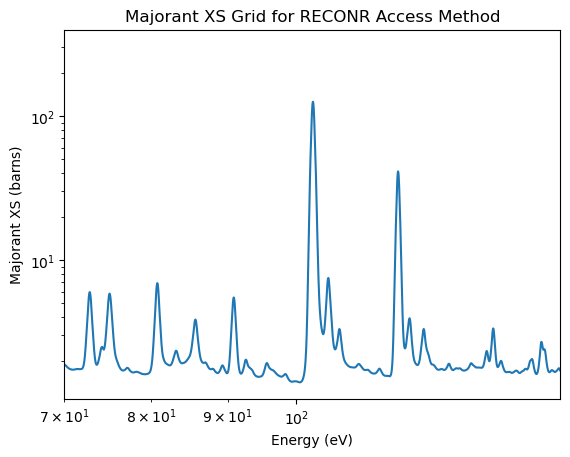

In [3]:
print(geometry.perf.summary())

plt.plot(geometry.reconr_e_grid, geometry.reconr_maj_xs_grid)
plt.xlim(70, geometry.reconr_e_grid[-1])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy (eV)")
plt.ylabel("Majorant XS (barns)")
plt.title("Majorant XS Grid for RECONR Access Method")  



/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/illustration.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


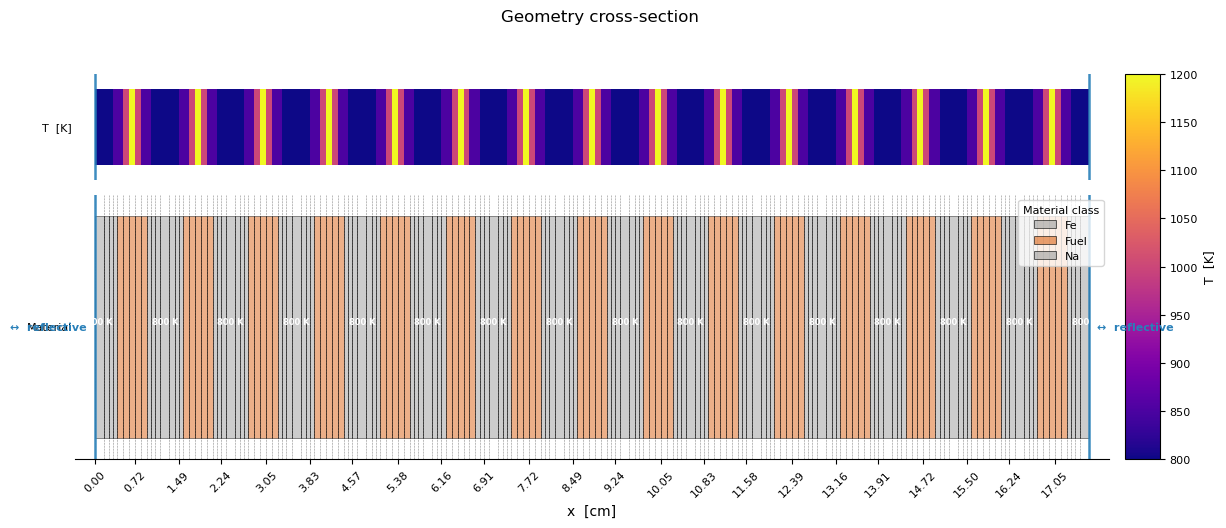

(<Figure size 1400x500 with 3 Axes>,
 <Axes: xlabel='x  [cm]', ylabel='Material'>)

In [4]:


src.illustration.draw(geometry)

/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/geometry_plot.py:454: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  GEOMETRY SUMMARY
  Span        : 0.0000 → 17.6654 cm   (Δ = 17.6654 cm)
  Regions     : 181
  BC left     : reflective
  BC right    : reflective

────────────────────────────────────────────────────────────────────────
  CLASS : FUEL
  Regions       : 75
  Total width   : 7.9775 cm
  T range       : 850 – 1200 K

  Unique compositions : 15  (out of 75 regions — sub-slabs with same composition grouped)

    ┌─ fuel_cell01_sub1  ×5 regions   T ∈ {850, 1000, 1200} K
    │   Nuclide         N [at/cm³]    at. frac    wt. frac
    │   ──────────  ──────────────  ──────────  ──────────
    │   U238            2.9955e-02      0.6440      0.7495
    │   Zr90            1.0583e-02      0.2275      0.1000
    │   Pu239           2.8043e-03      0.0603      0.0705
    │   Pu240           1.7482e-03      0.0376      0.0441
    │   Pu241           6.0673e-04      0.0130      0.0154
    │   Am241           4.8306e-04      0.0104      0.0122
    │   Pu238           2.1219e-04      0.0046      0.005

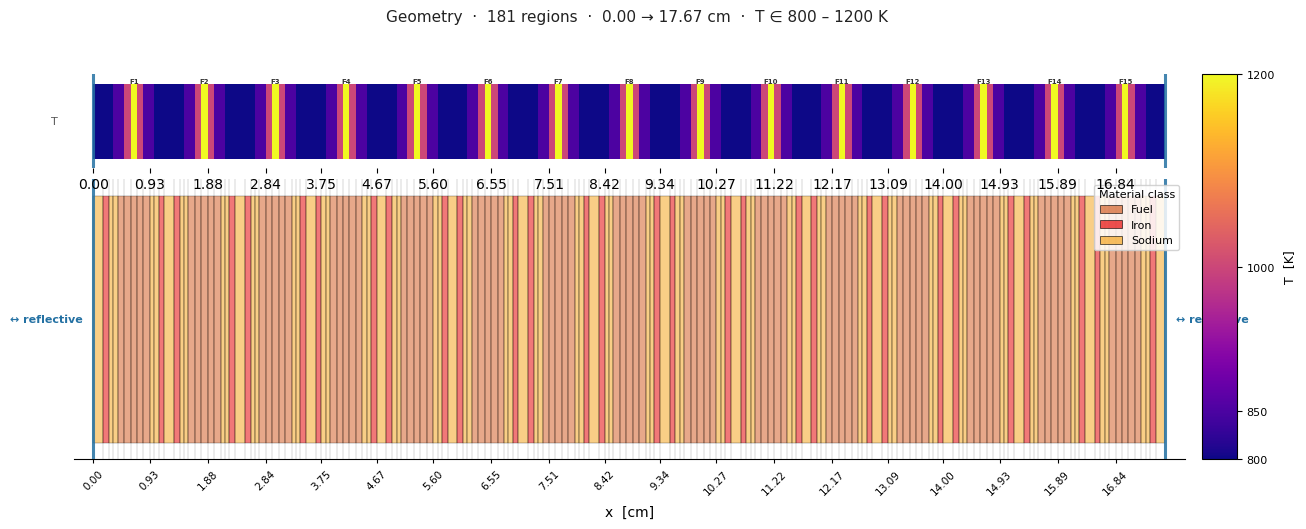

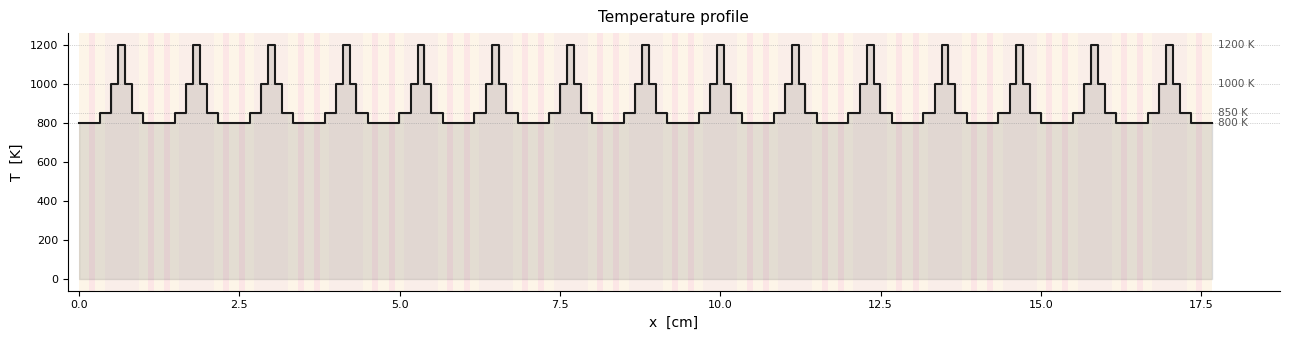

In [5]:
import src.geometry_plot as gp

# 1 — standalone functions
gp.draw(geometry)
gp.draw_temperature_profile(geometry)
gp.print_summary(geometry)




/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/source_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/source_plot.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


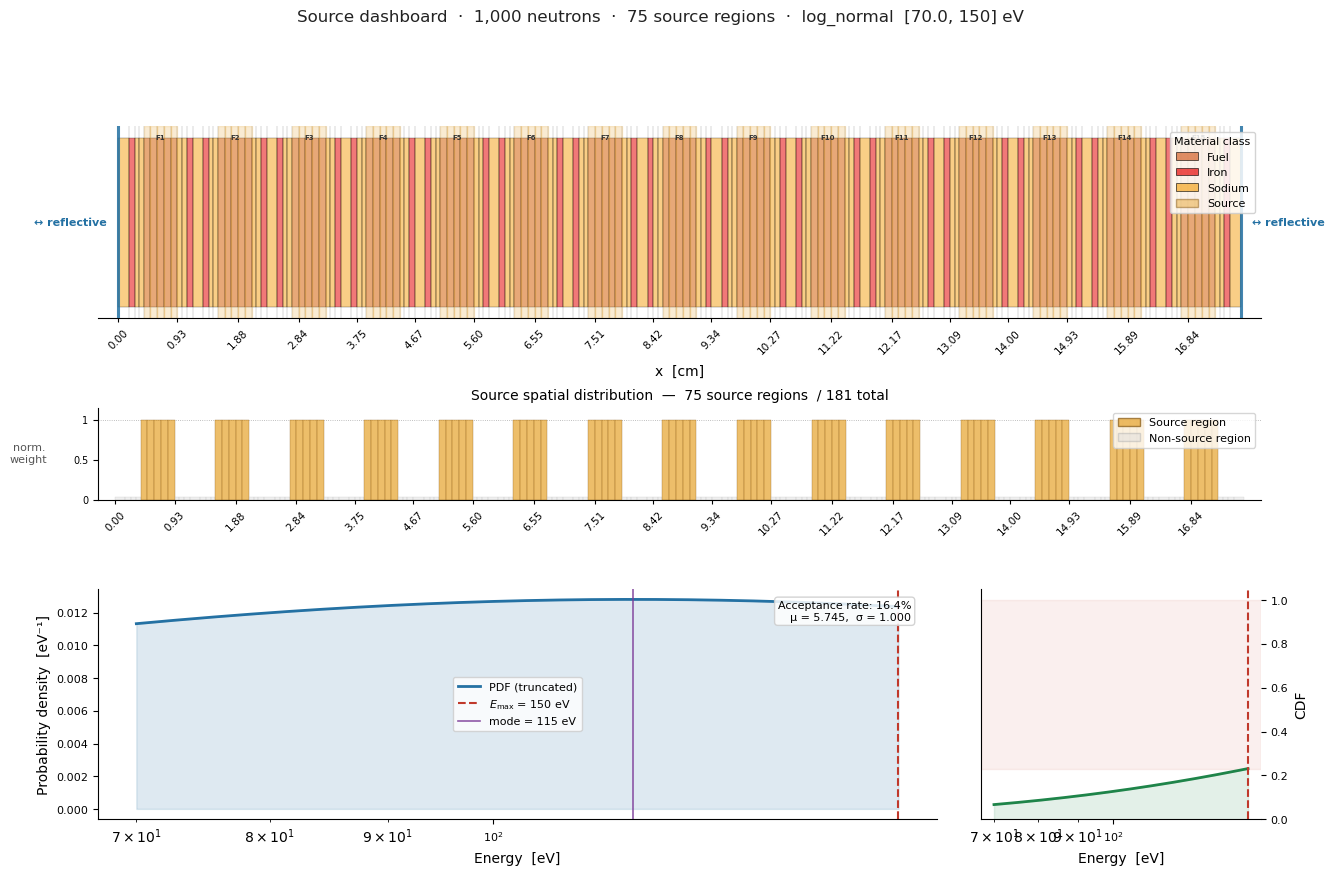

[SourcePlotter] Saved → source_dashboard.png


(<Figure size 1400x250 with 1 Axes>,
 <Axes: title={'center': 'Source spatial distribution  —  75 source regions  / 181 total'}, xlabel='x  [cm]', ylabel='norm.\nweight'>)

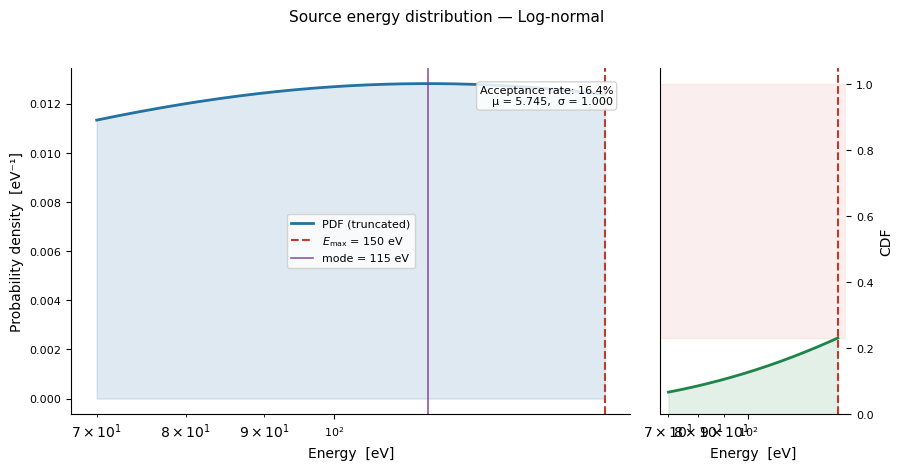

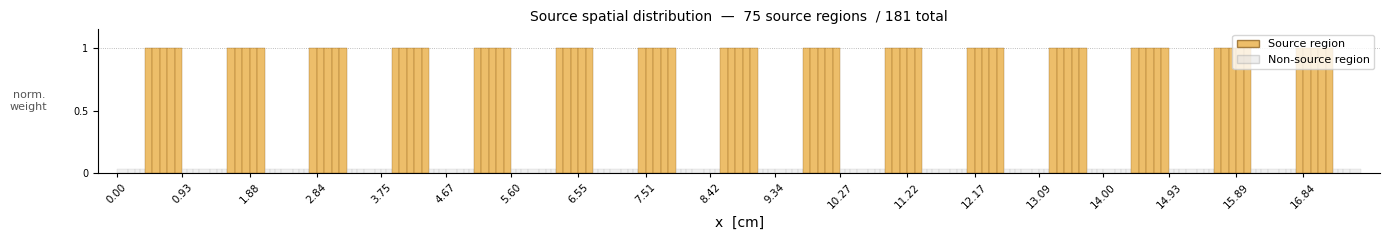

In [6]:
from src.source_plot import SourcePlotter, draw_source, draw_energy, draw_spatial

# full dashboard
p = SourcePlotter(source, geometry)
p.draw()
p.save("source_dashboard.png", dpi=200)

# individual panels
draw_energy(source)
draw_spatial(source, geometry)

In [7]:
source.neutron_nbr = 1000

batches = geometry.run_batch(source, n_batches=20, mode= "parallel")



 [Memory] Tracker started (poll interval: 1 ms)

[Parallel] Running 20 batches on 22 workers...

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source 

In [ ]:

xp_sim.export_cross_batch_stats(
                                batch_stats=batches,
                                geom=geometry,
                                print_to_console=True,
                                save_csv=True,
                                output_dir=None
                            )




  CROSS-BATCH STATISTICS

  FLUX TALLY [cm · src-n⁻¹]
  Group                               Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  0-0 eV                        0.0000e+00     0.0000e+00        inf
  0-1 eV                        0.0000e+00     0.0000e+00        inf
  1-10 eV                       0.0000e+00     0.0000e+00        inf
  10-100 eV                     2.2501e+00     2.7712e-02     0.0123
  100-1000 eV                   5.8855e+00     6.6567e-02     0.0113
  1000-10000 eV                 0.0000e+00     0.0000e+00        inf
  10000-10000000 eV             0.0000e+00     0.0000e+00        inf

  ABSORPTION RATE [reactions · src-n⁻¹]
  Region / Group                      Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  0.0-4.1 cm | 0-0 eV           0.0000e+00     0.0000e+00        inf
  0.0-4.1 cm | 0-1 eV           0.0000e+00     0.0000e+00        inf
  0.0-4.1